In [2]:
# Importing and setting up the libraries

# Standard library
import warnings

# Data manipulation & visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

# Reproducibility — always set a random seed!
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Setup complete")

✅ Setup complete


In [3]:
# Reading the file
filename = "../data/properties_final_irene.csv"
df = pd.read_csv(filename)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
df.head(5)

Shape: 12399 rows × 34 columns



,property_type,property_subtype,price,living_area_m2,bedrooms,bathrooms,address,postal_code,city,latitude,longitude,building_year,state_of_the_building,furnished,has_garage,parking_count,kitchen_equipped,has_elevator,facades,floors_total,has_garden,garden_area_m2,has_terrace,total_area_m2,epc_score,region,province,nearby_city,km_from_nearby_city,is_nearby_city_prestigious,floor_number,property_url,coord_swapped,price_per_m2
0,House,residence,550000.000,250.000,4.000,1.000,Rue des Nonnes 32A,4400,Flemalle,50.601,5.421,2019.000,New,0,1,1.000,Fully equipped,0,4.000,2.000,1,250.000,1,780.000,A+,Wallonia,Liège,Liège,11.800,0.000,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,2200.000
1,Apartment,apartment,200000.000,57.000,1.000,1.000,Avenue Louise 32A,1050,Elsene,50.835,4.357,NaN,Normal,0,0,NaN,NaN,1,2.000,NaN,0,NaN,1,NaN,B,Brussels,Brussels Capital Region,Bruxelles,1.800,0.000,2.000,https://immovlan.be/en/detail/apartment/for-sa...,False,3509.000
2,Apartment,duplex,189000.000,115.000,1.000,1.000,NaN,7500,Tournai,50.606,3.388,2010.000,Excellent,0,0,NaN,NaN,0,NaN,NaN,0,NaN,1,NaN,G,Wallonia,Hainaut,Tournai,0.100,0.000,NaN,https://immovlan.be/en/detail/duplex/for-sale/...,False,1643.000
3,House,residence,549000.000,399.000,3.000,3.000,Kerkstraat 20 + 20/1,3941,Eksel,51.153,5.391,NaN,Normal,0,1,NaN,NaN,0,4.000,3.000,1,NaN,1,590.000,NaN,Flanders,Limburg,Genk,22.100,0.000,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,1376.000
4,House,residence,330000.000,99.000,3.000,1.000,Quartier de Lohan 1,6980,La Roche En Ardenne,50.180,5.607,NaN,Excellent,1,1,1.000,Fully equipped,0,4.000,NaN,1,NaN,1,1036.000,D,Wallonia,Luxembourg,Verviers,48.900,0.000,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,3333.000


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 12399 entries, 0 to 12398
Data columns (total 34 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   property_type               12399 non-null  str    
 1   property_subtype            12399 non-null  str    
 2   price                       12399 non-null  float64
 3   living_area_m2              11557 non-null  float64
 4   bedrooms                    11987 non-null  float64
 5   bathrooms                   11036 non-null  float64
 6   address                     9949 non-null   str    
 7   postal_code                 12399 non-null  int64  
 8   city                        12399 non-null  str    
 9   latitude                    12397 non-null  float64
 10  longitude                   12397 non-null  float64
 11  building_year               7433 non-null   float64
 12  state_of_the_building       9541 non-null   str    
 13  furnished                   12399 non-null

In [5]:
df.groupby('property_type')['floor_number'].apply(lambda x: x.notna().mean())

property_type
Apartment   0.802
House       0.000
Name: floor_number, dtype: float64

In [128]:
df.groupby('has_garden')['garden_area_m2'].apply(lambda x: x.isna().sum())
#df.groupby('has_garage')['parking_count'].apply(lambda x: x.isna().sum())

has_garden
0    5743
1    3876
Name: garden_area_m2, dtype: int64

In [129]:
df[df['has_garage']==1]['parking_count'].describe()

count   4222.000
mean       1.861
std       29.254
min        1.000
25%        1.000
50%        1.000
75%        1.000
max     1885.000
Name: parking_count, dtype: float64

In [130]:

df[df['has_garage']==1]['parking_count'].median()

np.float64(1.0)

In [131]:
df['has_garden'].value_counts()

has_garden
1    6656
0    5743
Name: count, dtype: int64

In [132]:
df.groupby('province')['city'].nunique().sort_values(ascending=False)

province
Hainaut                    294
Namur                      236
Liège                      227
East Flanders              149
Luxembourg                 148
West Flanders              139
Antwerp                    136
Flemish Brabant            115
Limburg                     80
Walloon Brabant             66
Brussels Capital Region     22
Name: city, dtype: int64

In [133]:
df.groupby('region')['province'].unique()

region
Brussels                            [Brussels Capital Region]
Flanders    [Limburg, East Flanders, Antwerp, West Flander...
Wallonia    [Liège, Hainaut, Luxembourg, Namur, Walloon Br...
Name: province, dtype: object

In [134]:
df.groupby('property_type')['floors_total'].apply(lambda x: x.notna().mean())

property_type
Apartment   0.631
House       0.351
Name: floors_total, dtype: float64

In [135]:
df['floors_total'].corr(df['price'])

np.float64(-0.07241822086357161)

In [136]:
df.groupby('property_type')['kitchen_equipped'].apply(lambda x: x.notna().mean())

property_type
Apartment   0.286
House       0.265
Name: kitchen_equipped, dtype: float64

In [137]:
df.groupby('kitchen_equipped')['price'].median()

kitchen_equipped
Fully equipped       289750.000
Not equipped         325000.000
Partially equipped   189000.000
Super equipped       479000.000
Name: price, dtype: float64

In [6]:
# Columns to drop
COLS_TO_DROP = {
    "property_id":"Unique identifier,not required for prediction",
    "coord_swapped": "Not required, was done to get the info",
    "region": "Not needed as does not affect the price",
    #"price_per_m2":"We are considering target as price and living area is already present",
    "property_url": "unique",
    "postal_code":"large number of unique values",
    "floors_total":"Not required as wont affect much",
    "address": "Won't affect the price much",
    "city":"Not considering city, latitude and longiture will work for now",
    #"kitchen_equipped": "A lot of missing values",
    #"building_year": "Missing in 40.05 % of rows, dropping to avoid distorting timeline"
}

In [ ]:



def clean_data_final():
        # Working on copy of dataframe
    df_clean = df.copy()

    #Before dropping the columns using to find the values for total_area_m2

    if "total_area_m2" in df_clean.columns:
       exact_area = df_clean["price"]/df_clean["price_per_m2"]
       df_clean["total_area_m2"] = df_clean["total_area_m2"].fillna(exact_area)

    if "region" in df_clean.columns:
           region_median = df_clean.groupby(["property_type","region"])["total_area_m2"].transform
           ("median")
           df_clean["region"] = df_clean["region"].fillna(region_median)

    # Fallback 2: Group by Property Type + Province
    if "province" in df_clean.columns:
        province_median = df_clean.groupby(['property_type', 'province'])['total_area_m2'].transform("median")
        df_clean['total_area_m2'] = df_clean['total_area_m2'].fillna(province_median)
        
    # Fallback 3: Basic Property Type median
        type_median = df_clean.groupby(['property_type'])['total_area_m2'].transform("median")
        df_clean['total_area_m2'] = df_clean['total_area_m2'].fillna(type_median)


     # Drop only columns that exist (safe for re-runs)
    cols_present = [c for c in COLS_TO_DROP if c in df_clean.columns]
    df_clean = df_clean.drop(columns=cols_present)

    print(f"Dropped {len(cols_present)} column(s): {cols_present}")
    #print(df_clean.columns.tolist())
    print(f"Remaining shape: {df_clean.shape}")

    #Zero filling
    # If has_garage ==0 then parking_count== 0
    if "parking_count" in df_clean.columns and "has_garage" in df_clean.columns:
        df_clean.loc[df_clean["has_garage"]==0,"parking_count"]= df_clean.loc[
        df_clean["has_garage"]==0,"parking_count"].fillna(0)
    #if has_garden ==0 then garden_area_m2 is also 0
    if "garden_area_m2" in df_clean.columns and "has_garden" in df_clean.columns:
        df_clean.loc[df_clean["has_garden"] == 0, "garden_area_m2"] = df_clean.loc[
            df_clean["has_garden"] == 0, "garden_area_m2"
        ].fillna(0)

    #set floor number to 0 if the property type is a house

    if "floor_number" in df_clean.columns and "property_type" in df_clean.columns:
        df_clean.loc[
            df_clean["property_type"].str.lower() == "house", "floor_number"
        ] = df_clean.loc[
            df_clean["property_type"].str.lower() == "house", "floor_number"
        ].fillna(
            0
        )

    # 3. Conditional Median Filling
    #if parking count is 0 but has_garage is 1, we fill the value with the median, the parking count
    if "parking_count" in df_clean.columns and "has_garage" in df_clean.columns:
        garage_mask = df_clean["has_garage"] == 1
        parking_median = df_clean.loc[garage_mask, "parking_count"].median()
        if pd.isna(parking_median) or parking_median == 0:
            parking_median = 1
        df_clean.loc[garage_mask, "parking_count"] = df_clean.loc[
            garage_mask, "parking_count"
        ].fillna(parking_median)

    #if garden_area_m2 count is 0 but has_garden is 1, we fill the value with the median, the garden_area_m2
    if "garden_area_m2" in df_clean.columns and "has_garden" in df_clean.columns:
        garden_mask = df_clean["has_garden"] == 1
        garden_median = df_clean.loc[garden_mask, "garden_area_m2"].median()
        df_clean.loc[garden_mask, "garden_area_m2"] = df_clean.loc[
            garden_mask, "garden_area_m2"
        ].fillna(garden_median)

    # if living area missing,adding median Living Area 
    if "living_area_m2" in df_clean.columns:
        living_median = df_clean["living_area_m2"].median()
        df_clean["living_area_m2"] = df_clean["living_area_m2"].fillna(
            living_median
        )
    # Bedrooms replaced by median for houses and apartments differently
    if "bedrooms" in df_clean.columns:
       bedroom_median = df_clean.groupby(['property_type'])['bedrooms'].transform("median")
       df_clean["bedrooms"] = df_clean["bedrooms"].fillna(
             bedroom_median
       )

    # Bathrooms replaced by median for houses and apartments differently
    if "bathrooms" in df_clean.columns:
       bathroom_median = df_clean.groupby(['property_type'])['bathrooms'].transform("median")
       df_clean["bathrooms"] = df_clean["bathrooms"].fillna(
             bathroom_median
       )

    # Facades replaced by median for houses and apartments differently
    if "facades" in df_clean.columns:
       facades_median = df_clean.groupby(['property_type'])['facades'].transform("median")
       df_clean["facades"] = df_clean["facades"].fillna(
             facades_median
       
       )

     # Building Year -This will create a new column with the median filled in the building_year and missing_year will be 1
    if "building_year" in df_clean.columns:
        df_clean["building_year_is_missing"] = (
            df_clean["building_year"].isna().astype(int) #.isna() checks every row to see if the year is missing (returning True or False) and converts True to 1 and False to 0.
        )
        year_median = df_clean["building_year"].median()    #Filling the year with median
        df_clean["building_year"] = df_clean["building_year"].fillna(
            year_median
        )
        df_clean["building_year"] = df_clean["building_year"].round().astype(int)
       

    # 6.Filling kichen_equipped with unknow if any values missing
    if "kitchen_equipped" in df_clean.columns:
        df_clean["kitchen_equipped"] = df_clean["kitchen_equipped"].fillna(
            "Unknown"
        )

    # "state_of_the_building" with unknown if any values missing
    if "state_of_the_building" in df_clean.columns:
        df_clean["state_of_the_building"] = df_clean["state_of_the_building"].fillna(
            "Unknown"
        )  

    # Filling the epc_score with unknown
    if "epc_score" in df_clean.columns:
        df_clean["epc_score"] = df_clean["epc_score"].fillna(
            "Unknown"
        )                  

    #print(df_clean.columns.tolist())
    print(f"Remaining shape: {df_clean.shape}")
        
    return df_clean




In [16]:
def clean_data(df):
    df = df.copy()
    # Remove duplicate listings based on property_id or property_url
    id_col = "property_id" if "property_id" in df.columns else "property_url"
    df = df.drop_duplicates(subset=id_col)

   
   # 2. Drop irrelevant columns
    cols_present = [c for c in COLS_TO_DROP if c in df.columns]
    df = df.drop(columns=cols_present)

    # 3. Simple zero-filling rules--> If no garage,parking count must be 0
    if "parking_count" in df.columns and "has_garage" in df.columns:
        df.loc[df["has_garage"] == 0, "parking_count"] = 0

      # If no garden → garden_area_m2 must be 0
    if "garden_area_m2" in df.columns and "has_garden" in df.columns:
        df.loc[df["has_garden"] == 0, "garden_area_m2"] = 0

    # 4.  median filling for numeric columns
    numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # 5.Categorical columns filled with 'Unknown'
    categorical_cols = df.select_dtypes(include=["object"]).columns
    for col in categorical_cols:
        df[col] = df[col].fillna("Unknown")

    #print(df_clean.columns.tolist())
    print(f"Remaining shape: {df.shape}")
        
    return df

In [17]:
df = clean_data(df)

KeyError: Index(['property_url'], dtype='str')

In [18]:
df.columns.tolist()

['property_type',
 'property_subtype',
 'price',
 'living_area_m2',
 'bedrooms',
 'bathrooms',
 'latitude',
 'longitude',
 'building_year',
 'state_of_the_building',
 'furnished',
 'has_garage',
 'parking_count',
 'kitchen_equipped',
 'has_elevator',
 'facades',
 'has_garden',
 'garden_area_m2',
 'has_terrace',
 'total_area_m2',
 'epc_score',
 'province',
 'nearby_city',
 'km_from_nearby_city',
 'is_nearby_city_prestigious',
 'floor_number',
 'price_per_m2']

In [19]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[numeric_cols].corr()['price'].sort_values(ascending=False)

price                         1.000
bedrooms                      0.515
living_area_m2                0.513
bathrooms                     0.438
price_per_m2                  0.333
total_area_m2                 0.264
facades                       0.232
has_garage                    0.192
has_garden                    0.177
is_nearby_city_prestigious    0.151
latitude                      0.150
garden_area_m2                0.145
has_terrace                   0.113
building_year                 0.048
km_from_nearby_city           0.016
parking_count                 0.005
floor_number                  0.000
furnished                    -0.005
has_elevator                 -0.053
longitude                    -0.093
Name: price, dtype: float64

In [21]:
important_features = ['bedrooms', 'bathrooms', 'living_area_m2', 'total_area_m2',
                       'facades', 'has_garage', 'has_garden', 'latitude',
                       'property_type', 'province']

X = df[important_features]
y = df['price']

In [22]:
X.isnull().sum()

bedrooms          0
bathrooms         0
living_area_m2    0
total_area_m2     0
facades           0
has_garage        0
has_garden        0
latitude          0
property_type     0
province          0
dtype: int64

In [23]:
X.head()

,bedrooms,bathrooms,living_area_m2,total_area_m2,facades,has_garage,has_garden,latitude,property_type,province
0,4.000,1.000,250.000,780.000,4.000,1,1,50.601,House,Liège
1,1.000,1.000,57.000,630.000,2.000,0,0,50.835,Apartment,Brussels Capital Region
2,1.000,1.000,115.000,630.000,3.000,0,0,50.606,Apartment,Hainaut
3,3.000,3.000,399.000,590.000,4.000,1,1,51.153,House,Limburg
4,3.000,1.000,99.000,1036.000,4.000,1,1,50.180,House,Luxembourg


In [24]:
df_model = df.dropna(subset=['latitude'])
X = df_model[important_features]
y = df_model['price']
print(X.shape, y.shape)

(12390, 10) (12390,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [237]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9917, 11)
X_test: (2480, 11)


In [238]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_features = ['bedrooms', 'bathrooms', 'living_area_m2', 'total_area_m2',
                     'facades', 'has_garage', 'has_garden', 'latitude']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   #imputate the median for the numerical values
    ('scaler', StandardScaler())                     # Standardize the just filled missing values
])

In [239]:
categorical_features = ['property_type','province']

categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

In [240]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [241]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['bedrooms','bathrooms','living_area_m2',...,'property_type','province', 'region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset

In [275]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_train = lr_pipeline.predict(X_train)
y_pred_test = lr_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.5096655522678631
Test R²: 0.4064368236101302
Test MAE: 129368.5186944142


In [276]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)

y_pred_train = rf_pipeline.predict(X_train)
y_pred_test = rf_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.9500894548205622
Test R²: 0.503956329583936
Test MAE: 96459.06902265745


In [245]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor())
])

xgb_pipeline.fit(X_train, y_train)

y_pred_train = xgb_pipeline.predict(X_train)
y_pred_test = xgb_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.924309387670943
Test R²: 0.48272007524077154
Test MAE: 113009.05359280494


Iteration 2 with more features:

In [27]:
important_features = ['bedrooms', 'bathrooms', 'living_area_m2', 'total_area_m2',
                       'facades', 'has_garage', 'has_garden', 'latitude','longitude',
                       'property_type', 'province','state_of_the_building','epc_score',
                       'has_elevator','parking_count','garden_area_m2',
                       'is_nearby_city_prestigious']

X = df[important_features]
y = df['price']

In [28]:
df_model = df.dropna(subset=['latitude','is_nearby_city_prestigious'])
X = df_model[important_features]
y = df_model['price']
print(X.shape, y.shape)

(12390, 17) (12390,)


In [29]:
X.head()

,bedrooms,bathrooms,living_area_m2,total_area_m2,facades,has_garage,has_garden,latitude,longitude,property_type,province,state_of_the_building,epc_score,has_elevator,parking_count,garden_area_m2,is_nearby_city_prestigious
0,4.000,1.000,250.000,780.000,4.000,1,1,50.601,5.421,House,Liège,New,A+,0,1.000,250.000,0.000
1,1.000,1.000,57.000,630.000,2.000,0,0,50.835,4.357,Apartment,Brussels Capital Region,Normal,B,1,0.000,0.000,0.000
2,1.000,1.000,115.000,630.000,3.000,0,0,50.606,3.388,Apartment,Hainaut,Excellent,G,0,0.000,0.000,0.000
3,3.000,3.000,399.000,590.000,4.000,1,1,51.153,5.391,House,Limburg,Normal,Unknown,0,0.000,0.000,0.000
4,3.000,1.000,99.000,1036.000,4.000,1,1,50.180,5.607,House,Luxembourg,Excellent,D,0,1.000,0.000,0.000


In [30]:
X.isnull().sum()

bedrooms                      0
bathrooms                     0
living_area_m2                0
total_area_m2                 0
facades                       0
has_garage                    0
has_garden                    0
latitude                      0
longitude                     0
property_type                 0
province                      0
state_of_the_building         0
epc_score                     0
has_elevator                  0
parking_count                 0
garden_area_m2                0
is_nearby_city_prestigious    0
dtype: int64

In [284]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [285]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (9917, 18)
X_test: (2480, 18)


In [286]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_features = ['bedrooms', 'bathrooms', 'living_area_m2', 'total_area_m2',
                     'facades', 'has_garage', 'has_garden', 'latitude','longitude','has_elevator','garden_area_m2',
                     'parking_count']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   #imputate the median for the numerical values
    ('scaler', StandardScaler())                     # Standardize the just filled missing values
])

In [287]:
categorical_features = ['property_type','province','state_of_the_building','epc_score','region']

categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

In [288]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [289]:
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](18,)","['bedrooms','bathrooms','living_area_m2',...,'garden_area_m2', 'is_nearby_city_prestigious','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,18
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

In [290]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_train = lr_pipeline.predict(X_train)
y_pred_test = lr_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.5096655522678633
Test R²: 0.4064368236101302
Test MAE: 129368.5186944142


In [31]:
lr_pipeline.named_steps['preprocessor'].n_features_in_

NameError: name 'lr_pipeline' is not defined

In [292]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(max_depth=12, min_samples_leaf=5, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_train = rf_pipeline.predict(X_train)
y_pred_test = rf_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.7229963553269549
Test R²: 0.5116464582552207
Test MAE: 102880.73035189637


In [293]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(max_depth=6, n_estimators=200,learning_rate=0.05,
                           min_child_weight=5, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)

y_pred_train = xgb_pipeline.predict(X_train)
y_pred_test = xgb_pipeline.predict(X_test)

print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

Train R²: 0.8312675096879396
Test R²: 0.49982351567576344
Test MAE: 98944.54961567541


In [169]:
import joblib
joblib.dump(xgb_pipeline, 'best_model.joblib')

['best_model.joblib']

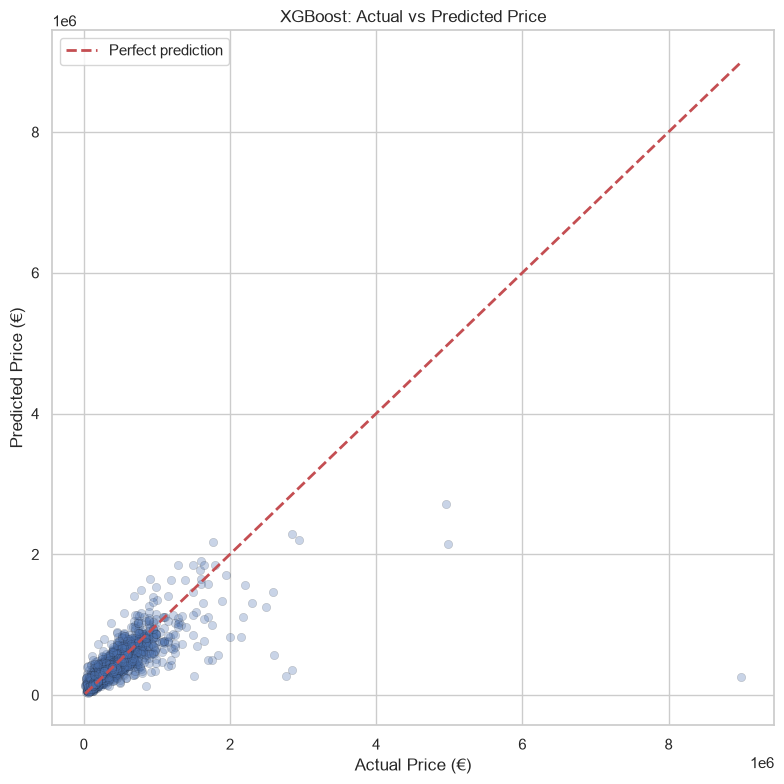

In [170]:
import matplotlib.pyplot as plt

y_pred_test = xgb_pipeline.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, alpha=0.3, edgecolor='k', linewidth=0.3)

# perfect-prediction reference line (y = x)
min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual Price (€)')
plt.ylabel('Predicted Price (€)')
plt.title('XGBoost: Actual vs Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()